# Variational PET Reconstruction with PD3O and WCRR

* This notebook demonstrates variational PET reconstruction using a learned prior integrated within the SIRF/CIL framework.
* It implements the PD3O (Primal-Dual Three-Operator) optimization algorithm.
* The regularization uses a Weakly Convex Ridge Regularizer (WCRR) with pre-trained weights from the `sirf.contrib.PnP_with_DeepInverse` module.

## Initialize libraries and set data paths

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sirf.STIR as pet
from sirf.Utilities import examples_data_path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrize as P
from cil.optimisation.algorithms import PD3O
from cil.optimisation.functions import KullbackLeibler, IndicatorBox, Function

msg_red = pet.MessageRedirector('info.txt', 'warnings.txt', 'errors.txt')
data_path = os.path.join(examples_data_path('PET'), 'thorax_single_slice')

## Define FOV utilities and simulate noisy PET acquisition data

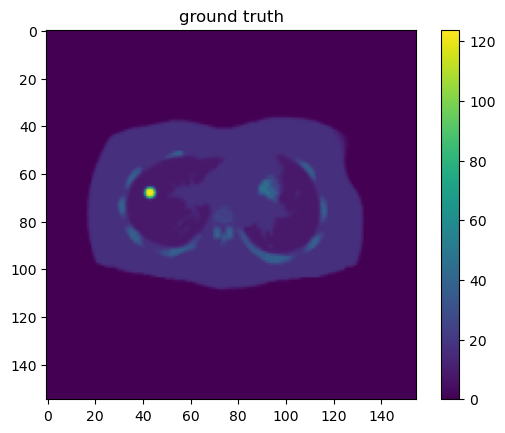

In [2]:
def make_cylindrical_fov(image):
    arr = image.as_array()
    nz, ny, nx = arr.shape
    yy, xx = np.ogrid[:ny, :nx]
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    radius = min(nx, ny) / 2.0
    mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
    arr *= mask[None, :, :]
    image.fill(arr)
    return image

def build_problem(count_scale_factor=2.0): 
    image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * count_scale_factor
    template = pet.AcquisitionData(os.path.join(data_path, 'template_sinogram.hs'))

    acq_model = pet.AcquisitionModelUsingRayTracingMatrix()
    acq_model.set_num_tangential_LORs(5) 
    acq_model.set_up(template, image)

    clean_data = acq_model.forward(image)
    acquired_data = clean_data.clone()
    acquired_data.fill(np.random.poisson(clean_data.as_array()).astype(np.float32))

    return image, acquired_data, acq_model

ground_truth, acquired_data, acq_model = build_problem()

plt.imshow(ground_truth.as_array()[0,:,:])
plt.colorbar()
plt.title('ground truth')
plt.show()

## Perform baseline OSEM reconstruction for comparison

In [3]:
num_subsets = 4
num_subiterations = 100

osem_obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
osem_obj_fun.set_acquisition_model(acq_model)

osem = pet.OSMAPOSLReconstructor()
osem.set_objective_function(osem_obj_fun)
osem.set_num_subsets(num_subsets)
osem.set_num_subiterations(num_subiterations)

osem_initial = ground_truth.get_uniform_copy(ground_truth.max() * 0.15)
make_cylindrical_fov(osem_initial)

osem.set_current_estimate(osem_initial)
osem.set_up(osem_initial)
osem.process()
osem_recon = osem.get_output()

## Implement WCRR neural network prior and CIL optimization function wrapper

In [4]:
class ZeroMean(nn.Module):
    def forward(self, x): return x - torch.mean(x, dim=(1, 2, 3), keepdim=True)

class WCRR(nn.Module):
    def __init__(self, sigma, weak_convexity, device="cpu", pretrained=None):
        super().__init__()
        nb_channels=[1, 4, 8, 64]
        filter_sizes=[5, 5, 5]
        self.nb_filters = nb_channels[-1]
        self.filter_size = sum(filter_sizes) - len(filter_sizes) + 1
        self.filters = nn.Sequential(*[
            nn.Conv2d(nb_channels[i], nb_channels[i + 1], filter_sizes[i], padding=filter_sizes[i] // 2, bias=False)
            for i in range(len(filter_sizes))
        ])
        P.register_parametrization(self.filters[0], "weight", ZeroMean())
        self.dirac = torch.zeros(1, 1, 2 * self.filter_size - 1, 2 * self.filter_size - 1)
        self.dirac[:, :, self.filter_size - 1, self.filter_size - 1] = 1.0
        self.scaling = nn.Parameter(torch.log(torch.tensor(2.0) / sigma) * torch.ones(1, self.nb_filters, 1, 1))
        self.beta = nn.Parameter(torch.tensor(4.0))
        self.weak_cvx = weak_convexity
        if pretrained: self.load_state_dict(torch.load(pretrained, map_location=device))

    def smooth_l1(self, x): return torch.clip(x**2, 0.0, 1.0) / 2 + torch.clip(torch.abs(x), 1.0) - 1.0
    def grad_smooth_l1(self, x): return torch.clip(x, -1.0, 1.0)
    def get_conv_lip(self):
        impulse = self.filters(self.dirac)
        for filt in reversed(self.filters): impulse = F.conv_transpose2d(impulse, filt.weight, padding=filt.padding)
        return torch.fft.fft2(impulse, s=[256, 256]).abs().max()
    def conv(self, x): return self.filters(x / torch.sqrt(self.get_conv_lip()))
    def grad(self, x):
        g = self.conv(x) * torch.exp(self.scaling)
        g = (self.grad_smooth_l1(torch.exp(self.beta) * g) - self.grad_smooth_l1(g) * self.weak_cvx) * torch.exp(-self.scaling)
        x_out = g / torch.sqrt(self.get_conv_lip())
        for filt in reversed(self.filters): x_out = F.conv_transpose2d(x_out, filt.weight, padding=filt.padding)
        return x_out
    def g(self, x):
        r = self.conv(x) * torch.exp(self.scaling)
        r = (self.smooth_l1(torch.exp(self.beta) * r) * torch.exp(-self.beta) - self.smooth_l1(r) * self.weak_cvx)
        return (r * torch.exp(-2 * self.scaling)).sum(dim=(1, 2, 3))

class WCRRCIL(Function):
    def __init__(self, lamb=0.01, scale=0.5):
        super().__init__()
        self.lamb, self.scale = lamb, scale
        self.model = WCRR(sigma=0.1, weak_convexity=0.0)
        path = os.path.abspath(os.path.join(os.getcwd(), '..', 'Python', 'sirf', 'contrib', 'PnP_with_DeepInverse', 'WCRR_bilevel_JFB_for_CT.pt'))
        weights = torch.load(path, map_location='cpu')
        new_w = {k.replace("regularizer.", ""): v for k, v in weights.items() if k.startswith("regularizer.")}
        self.model.load_state_dict(new_w, strict=False)

    def __call__(self, x):
        t = torch.from_numpy(x.as_array()).float().unsqueeze(0)
        return self.lamb * float(self.model.g(self.scale * t).item()) / self.scale**2

    def gradient(self, x, out=None):
        t = torch.from_numpy(x.as_array()).float().unsqueeze(0)
        grad = self.model.grad(self.scale * t)[0].detach().cpu().numpy()
        if out is None: out = x.get_uniform_copy()
        out.fill(grad * self.lamb / self.scale)
        return make_cylindrical_fov(out)

## Configure and execute the PD3O optimization algorithm

In [5]:
f = KullbackLeibler(b=acquired_data, eta=(acquired_data * 0 + 1e-5))
g = IndicatorBox(lower=0)
wcrr_cil = WCRRCIL(lamb=0.01, scale=0.5)

gamma = 0.5
delta = 1. / (gamma * acq_model.norm()**2)
setattr(PD3O, 'update_objective', lambda self: 0.)

pd3o = PD3O(f=wcrr_cil, g=g, h=f, operator=acq_model, delta=delta, gamma=gamma, 
            initial=osem_initial.clone(), update_objective_interval=4)
pd3o.run(100)

  0%|          | 0/100 [00:00<?, ?it/s]

no additive term added
no unnormalisation applied
no background term added
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term a

## Visualize and compare reconstructions using unified intensity scaling 

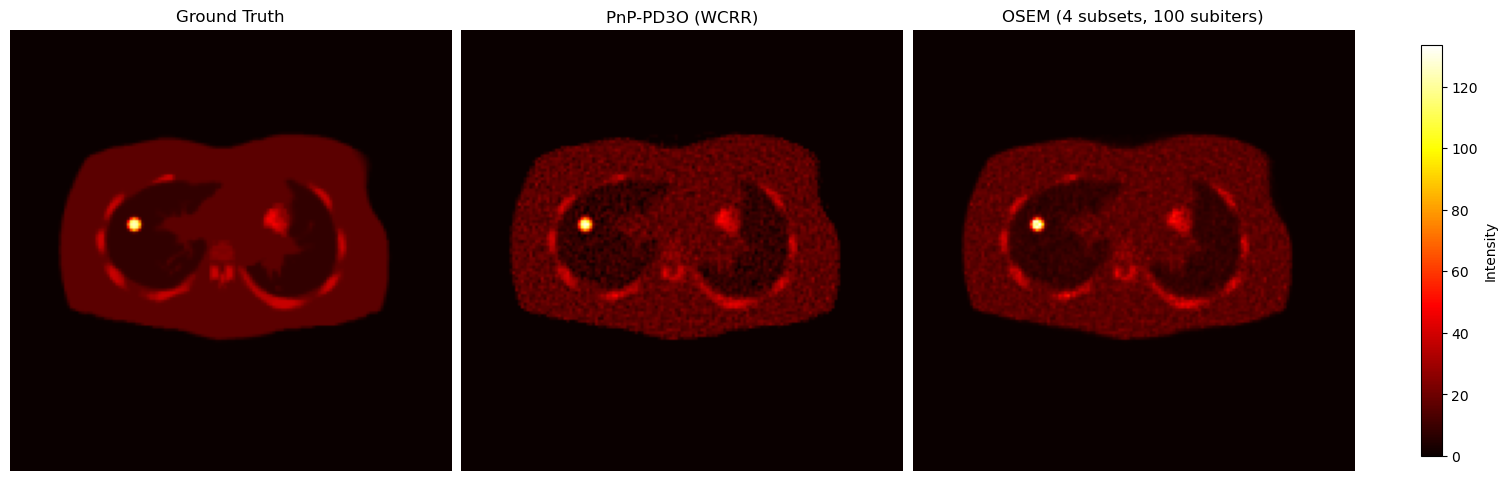

In [6]:
gt_arr = ground_truth.as_array()[0]
pd3o_arr = pd3o.solution.as_array()[0]
osem_arr = osem_recon.as_array()[0]

vmax = max(gt_arr.max(), pd3o_arr.max(), osem_arr.max())
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

axes[0].imshow(gt_arr, cmap="hot", vmin=0, vmax=vmax)
axes[0].set_title('Ground Truth'); axes[0].axis('off')

axes[1].imshow(pd3o_arr, cmap="hot", vmin=0, vmax=vmax)
axes[1].set_title('PnP-PD3O (WCRR)'); axes[1].axis('off')

im = axes[2].imshow(osem_arr, cmap="hot", vmin=0, vmax=vmax)
axes[2].set_title(f'OSEM ({num_subsets} subsets, {num_subiterations} subiters)'); axes[2].axis('off')

fig.colorbar(im, ax=axes, shrink=0.85, label='Intensity')
plt.show()